<a href="https://colab.research.google.com/github/r-okotie179/diseaseModelling/blob/main/culling_and_policy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This document applies culling logic to the initial `test.ipynb` file with extensions focusing on writing a custom heatmap function for better visualisations and varying different aspects of the code.



In [1]:
pip install binarytree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 kB 9.7 MB/s eta 0:00:00


In [2]:
#imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from binarytree import tree, Node
from math import floor, sqrt
import networkx as nx

/usr/local/lib/python3.13/dist-packages/binarytree/__init__.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


Distribution of cattle.; I don't actually know how they are distributed so this could be a point that the model could refine.

In [3]:
x = np.linspace(0.1, 100, 1000)
a = 40 # median
s_factor = 25
f_range = np.ceil((1/a) * (np.exp(s_factor*(x**(1/x))) -1)/(np.exp(s_factor) - 1) + np.abs(a-a/2) * np.sin(x*x + s_factor + np.sin(s_factor * (x**x))) + a)

In [4]:
scale = 10 # size of gridding

def farmland(n): # output n nodes
  farmlands = []
  for each_farm in range(n):
    nc = np.random.choice(f_range).astype(int)
    position = (np.random.uniform(-scale,scale), np.random.uniform(-scale,scale))
    farmlands.append([nc,position])
  df_farms = pd.DataFrame(farmlands, columns=['Cattle No.', 'Position'])
  return df_farms # dataframe

I do understand this, but doing leetcodes and cses.fi questions may help with reinfocing concepts (for application)

In [5]:
'''
@brewingacupofdata might be the goat; I have followed through his tutorial rather than using Claude's
'''

class MyNode(Node):
  def __init__(self, _id, data, axis, idx):
    super().__init__(_id)
    self.data = data
    self.axis = axis
    self.idx = idx

class KD_Tree:
  def __init__(self, data):
    self.data = data
    self.tree = None

  def _build(self, points, depth): # this is an internal function meaning it can only be called in this class
    k = len(points.columns) # assuming data is in pandas.DataFrame
    _axis = depth % k
    _column = points.columns[_axis]


    if len(points) == 0:
      return None
    objects_list = points.sort_values(by=[_column], ascending=True) # sorting data based on pandas notation
    if len(objects_list)%2 == 0:
      median_idx = int(len(objects_list)/2)
    else: # if odd
      median_idx = floor(len(objects_list)/2)

    # numpy stores data like numpy.float64 which isn't unpacked in different libraries
    node = MyNode(_id = round(objects_list.iloc[median_idx][_column].item(), 3),
                  data = objects_list.iloc[median_idx],
                  axis = _column,
                  idx = median_idx)
    node.left = self._build(objects_list.iloc[0:median_idx], depth+1)
    node.right = self._build(objects_list.iloc[median_idx+1:], depth+1)
    return node

  def build(self):
    self.tree = self._build(self.data, depth=0)

  #####

  def _nearest(self, query, node, best_node, best_distance):
    # node = current_node
    if not node:
      return best_node, best_distance

    d = np.linalg.norm(query.values[0] - node.data.values).item() # assuming query is pd.DataFrame row

    if d < best_distance:
      best_node = node
      best_distance = d

    # now deciding which side of tree to progress down

    if query[node.axis].values[0] < node.data[node.axis]:
      good_side = node.left
      bad_side = node.right
    else:
      good_side = node.right
      bad_side = node.left

    best_node, best_distance = self._nearest(query, good_side, best_node, best_distance)

    if abs(node.data[node.axis] - query[node.axis].values[0]) < best_distance:
      best_node, best_distance = self._nearest(query, bad_side, best_node, best_distance)

    return best_node, best_distance # a successful recursive algorithm

  #####

  def _k_nearest(self, query, node, k_list, k):
    if not node:
        return k_list

    d = np.linalg.norm(query.values[0] - node.data.values).item()

    if len(k_list) < k:
        k_list.append([node, d])
    else:
        worst_idx = max(range(len(k_list)), key=lambda i: k_list[i][1])
        if d < k_list[worst_idx][1]:
            k_list[worst_idx] = [node, d]

    if query[node.axis].values[0] < node.data[node.axis]:
        good_side, bad_side = node.left, node.right
    else:
        good_side, bad_side = node.right, node.left

    k_list = self._k_nearest(query, good_side, k_list, k)

    # prune condition: only descend bad_side if it could still contain
    # a point closer than your current worst (or you don't have k yet)
    if len(k_list) < k:
        should_check_bad_side = True
    else:
        worst_idx = max(range(len(k_list)), key=lambda i: k_list[i][1])
        should_check_bad_side = abs(node.data[node.axis] - query[node.axis].values[0]) < k_list[worst_idx][1]

    if should_check_bad_side:
        k_list = self._k_nearest(query, bad_side, k_list, k)

    return k_list

  ######

  def get_nn(self, query): # actually calling the nearest neighbour
    return self._nearest(query, self.tree, best_node = None, best_distance = np.inf)

  def get_knn(self, query, k):
    return self._k_nearest(query, self.tree, k_list=[], k=k)

Networks, this was by far the better approach.

In [6]:
sample = farmland(85)

G = nx.DiGraph()

# node creation
# node attributes are lists so that a time series plot can be constructed
for idx, farm in sample.iterrows():
  G.add_node(idx,
    position=farm['Position'],
    N=farm['Cattle No.'],
    S=[farm['Cattle No.']],
    I=[0],
    D=[0],
    dS = 0,
    dI = 0,
    dD = 0,
    counter = 0,
    detected = False
  )

#v = G.nodes[5]['N']
#print(np.array(v))

In [7]:
def u(a,b): # node characteristics
  a_num = G.nodes[a]['N']
  b_num = G.nodes[b]['N']
  a_pos = np.array(G.nodes[a]['position'])
  b_pos = np.array(G.nodes[b]['position'])
  u = (a_num * np.linalg.norm(a_pos - b_pos)) / b_num
  u = (np.log(u+0.001)) # to avoid log or 0 error
  return u.astype('float')

def f(a,b):
  z = u(a,b)
  q = (2/np.pi) * np.arctan(z)
  return np.abs(q)

In [8]:
# edge creation
k=9 # slider pararmeter

pos = nx.get_node_attributes(G, 'position')
pos_attr = pd.DataFrame(list(pos.values()), columns=['x','y'])
kdt = KD_Tree(pos_attr)
kdt.build()

for node_idx in range(len(sample)):
  node = G.nodes[node_idx]

  # query must be a DataFrame
  qry = pos_attr.iloc[[node_idx]]
  neighbours = kdt.get_knn(qry, k)

  for idx in range(k):
    comp_node_obj, comp_dist = neighbours[idx]
    comp_node = sample.loc[comp_node_obj.data.name]
    #print(f"{comp_node.name}\n")
    n = node_idx
    c = comp_node.name
    p = f(n, c)
    rand = np.random.uniform(0, 1)
    dnar = np.random.uniform(0,1) # there is now random chance of connection, since I don't want to spend more time on this
    #plt.scatter(node_idx, p)
    if rand <= dnar:
      G.add_edge(n, c, weight=p)

#plt.ylim(0,1)
#plt.grid(alpha=0.77)
#plt.show()

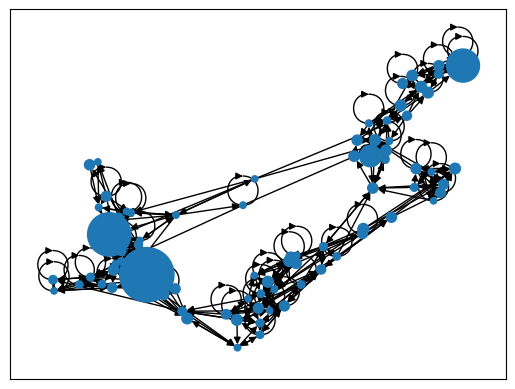

In [9]:
#pos = nx.nx_pydot.graphviz_layout(G, prog="dot")
pos = nx.spring_layout(G, seed=7)
node_sizes = [G.nodes[node]['N'] for node in G.nodes]

nx.draw_networkx(G, pos=pos, node_size=node_sizes, arrows=True, with_labels=False)

These values are arbitrary; I will try to understand how to select actual good values. This will be done against the true data (if I get access to it).

In [10]:
alpha=0.1
beta=0.1
gamma=0.1
phi = 0.002 # 0.2% chance of randomly being infected

In [11]:
def delta_s(s, i, t):
  e = beta * s * i * t
  return np.random.poisson(lam=e)

def delta_d(i, t):
  e = alpha * i * t
  return np.random.poisson(lam=e)

In [12]:
def inter_sum(node):
  isum = 0 # prob shouldn't name variable 'sum'
  for neigh in G.predecessors(node):
    w = G[neigh][node]['weight']
    i = G.nodes[neigh]['I'][-1]
    n = G.nodes[neigh]['N']
    isum += w * i / n
  return isum

def inter_s(node, s, i, dt): # there is a change in the equation
  e = beta * i
  gam = gamma * inter_sum(node)
  lba = s * (e + gam) * dt
  return np.random.poisson(lam=(lba))

def inter_farm(node, t, step):
    si = G.nodes[node]['S'][-1]
    ii = G.nodes[node]['I'][-1]
    di = G.nodes[node]['D'][-1]

    old_si = si
    old_ii = ii
    old_di = di

    if step == 0:
        # there is a .2% of a given cattle on a farm being infected at a given timestep
        rand_phi = np.random.uniform(0,1)
        initial_i = 0 if rand_phi > phi else 1
        si -= initial_i
        ii += initial_i

    x = min(inter_s(node, si, ii, t), si)
    y = min(delta_d(ii, t), ii)

    i2 = ii + x - y
    s2 = si - x
    d2 = di + y

    G.nodes[node]['dS'] = s2 - old_si
    G.nodes[node]['dI'] = i2 - old_ii
    G.nodes[node]['dD'] = d2 - old_di

In [13]:
def delta_helper(node):
  s = G.nodes[node]['S'][-1] + G.nodes[node]['dS']
  G.nodes[node]['S'].append(s)

  i = G.nodes[node]['I'][-1] + G.nodes[node]['dI']
  G.nodes[node]['I'].append(i)

  d = G.nodes[node]['D'][-1] + G.nodes[node]['dD']
  G.nodes[node]['D'].append(d)

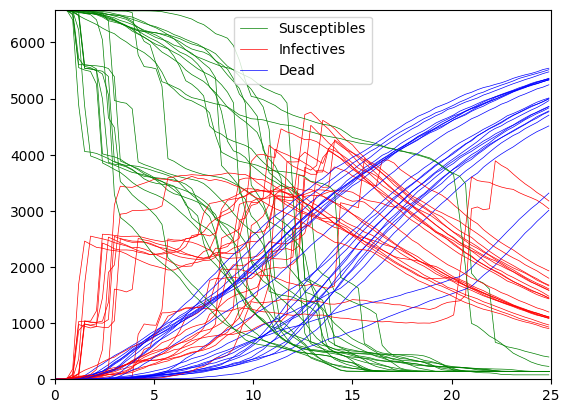

In [14]:
tot = np.array([G.nodes[node]['N'] for node in G.nodes])
total = tot.sum()

for tung in range(102):
  for node in G.nodes:
    # resets
    G.nodes[node]["S"] = [int(G.nodes[node]["N"])]
    G.nodes[node]["I"] = [0]
    G.nodes[node]["D"] = [0]
    G.nodes[node]["dS"] = 0
    G.nodes[node]["dI"] = 0
    G.nodes[node]["dD"] = 0

  time_range = 25 # days
  dt = .3 #day

  for step in range(int(time_range / dt)):
    for node in G.nodes:
      inter_farm(node, dt, step)

    for node in G.nodes:
      delta_helper(node)

  # collect the sum of attributes across the network
  s_matrix = np.array([G.nodes[node]['S'] for node in G.nodes])
  s = s_matrix.sum(axis=0).tolist()

  i_matrix = np.array([G.nodes[node]['I'] for node in G.nodes])
  i = i_matrix.sum(axis=0).tolist()

  d_matrix = np.array([G.nodes[node]['D'] for node in G.nodes])
  d = d_matrix.sum(axis=0).tolist()

  t = [step * dt for step in range(len(s))]

  plt.plot(t, s, color='g', lw=0.5, label='Susceptibles'if tung==0 else '')
  plt.plot(t, i, color='r', lw=0.5, label='Infectives' if tung==0 else '')
  plt.plot(t, d, color='b', lw=0.5, label='Dead' if tung==0 else '')

plt.xlim(0, time_range)
plt.ylim(0, total)
plt.legend()

plt.show()

Below is the culling logic specifically; where if there is an infective on a farm, after a given period, all animals on that farm will be culled.

This model assumes data completeness (that farmers would know instantaneously that an animal is infected) but the dead time -- I assume -- negates that partially.

Below is the pseudocode of my intention:

```
## pseudo for the code
def single_culling(graph_object, dead_time, iterations, simulation_duration): #graph, hours, num, days
    '''
    Within the loop of the interfarm dynamics, add on these points, as well as adding on the node characteristics of farm counter and farm.detected

    '''
    simulation_run()
    for each_farm where delta_I > 0 and not farm.detected: # for each farm where there is the patient zero
        farm.counter +=1 #counter for hours that pass after infective is present
        farm.detected = True # only do this for the first instance, if a new infective is found in the farm, it doesnt matter

    for each_farm:
        if farm.counter >= dead_time:
            farm.dead = farm.population
            farm.counter = 0
    # update plotting dynmaics

single_culling(G, 24, 100, 365) #24 hours
plt.show()
```

In [15]:
def culling(dead_time, iterations, simulation_duration, neighbour_culling = False):
    # subsequent model will use population (and have some uncertainty to account for testing and false positives
    census = np.array([G.nodes[node]['N'] for node in G.nodes])
    census = census.sum()

    for itr in range(iterations):
        for node in G.nodes:
            # resets
            G.nodes[node]["S"] = [int(G.nodes[node]["N"])]
            G.nodes[node]["I"] = [0]
            G.nodes[node]["D"] = [0]
            G.nodes[node]["dS"] = 0
            G.nodes[node]["dI"] = 0
            G.nodes[node]["dD"] = 0
            G.nodes[node]["counter"] = 0
            G.nodes[node]["detected"] = False
            G.nodes[node]["culled"] = False

        time_range = simulation_duration # days
        dt = 1/24 # hour; how to include counter that could be agnostic to whatever dt is

        for step in range(int(time_range / dt)):
            for node in G.nodes:
                if not G.nodes[node]["culled"]:
                    inter_farm(node, dt, step)

            for node in G.nodes:
                if G.nodes[node]["culled"]:
                    G.nodes[node]["S"].append(0)
                    G.nodes[node]["I"].append(0)
                    G.nodes[node]["D"].append(G.nodes[node]["N"])
                    continue

                delta_helper(node)

                if G.nodes[node]["dI"] > 0 and not G.nodes[node]["detected"]:
                    G.nodes[node]["detected"] = True

                if G.nodes[node]["detected"]:
                    G.nodes[node]["counter"] += 1 #counter. in unit dependent on dt

                if G.nodes[node]["counter"] >= dead_time:
                    # override the calculated value
                    G.nodes[node]["culled"] = True

                    G.nodes[node]["D"][-1] = G.nodes[node]["N"]
                    G.nodes[node]["S"][-1] = 0
                    G.nodes[node]["I"][-1] = 0

        # collect the sum of attributes across the network
        s_matrix = np.array([G.nodes[node]['S'] for node in G.nodes])
        s = s_matrix.sum(axis=0).tolist()

        i_matrix = np.array([G.nodes[node]['I'] for node in G.nodes])
        i = i_matrix.sum(axis=0).tolist()

        d_matrix = np.array([G.nodes[node]['D'] for node in G.nodes])
        d = d_matrix.sum(axis=0).tolist()

        t = [step * dt for step in range(len(s))]

        plt.plot(t, s, color='g', lw=0.5, label='Susceptibles'if itr==0 else '')
        plt.plot(t, i, color='r', lw=0.5, label='Infectives' if itr==0 else '')
        plt.plot(t, d, color='b', lw=0.5, label='Dead' if itr==0 else '')

        plt.xlim(0, time_range)
        plt.ylim(0, census)

        plt.xlabel("Time (days)")
        plt.ylabel("No. Cattle")

        plt.legend()

It's quite fascinating that there is such a spread of the disease across the farm. I will adjust gamma values to see if the dead plateaus (and some farms are cushioned)

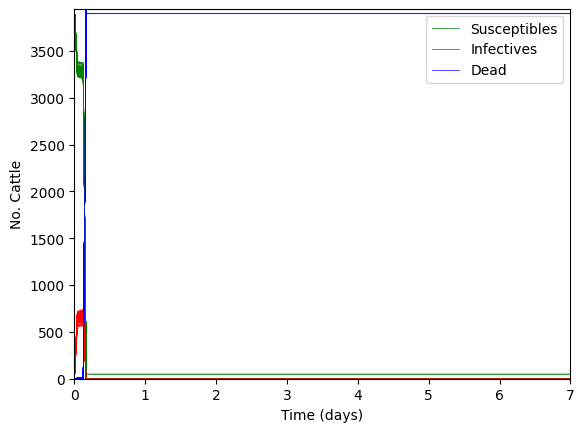

In [ ]:
culling(4, 100, 7)
plt.show()

This is the subsequent test.

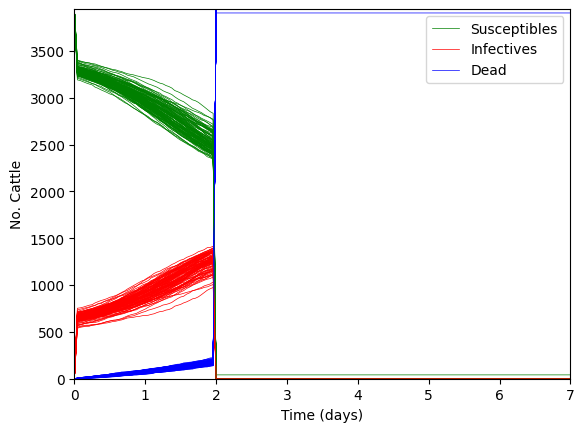

In [ ]:
gamma=0.00000001
alpha = 0.1
beta = 0.01

culling(48, 100, 7)
plt.show()

There is a saturation error, where since every farm has an infected point (this is by definition I have realised in the interfarm plot), I will improve parts of the network setup code the `inter_farm()` function to make sure that I can actually do analysis of stuff (to then write a small report on).

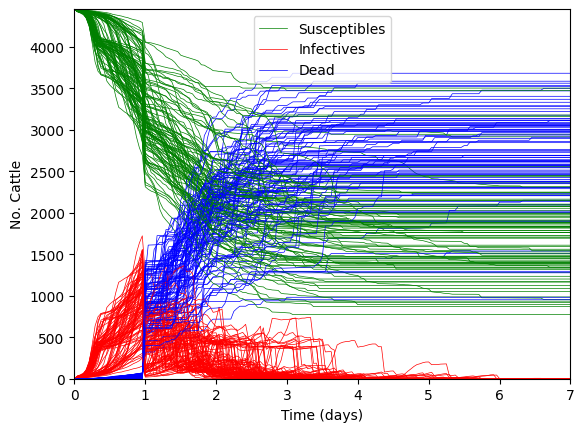

In [ ]:
alpha = 0.1
beta = 0.1
gamma = 0.1
phi = 0.2

culling(24,100,7)

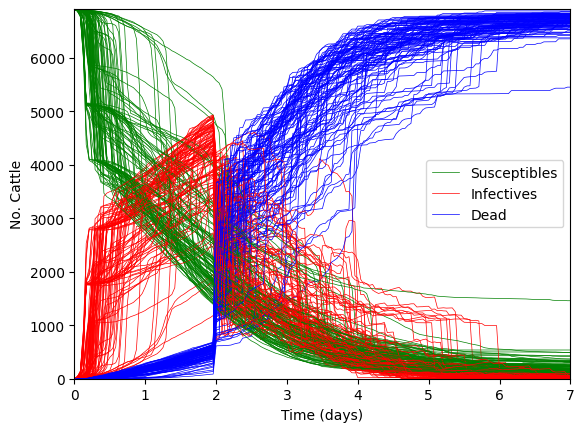

In [ ]:
culling(48, 100, 7)

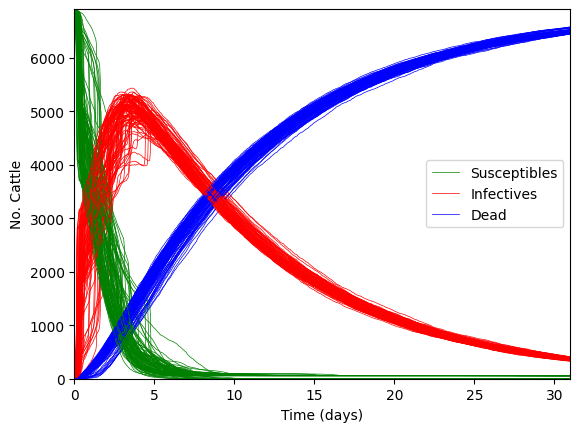

In [ ]:
culling(10000, 100, 31)

Given these tests were good, applying different parameters of gamma, alpha and beta to understand when culling methods are best. It would be interesting to try to quantify this impact and so I will try to writeup a report for this, that tries to qualitatively describe when culling policies are most appropriate as well as trying to attribute a cost to implementing them.

An ideal endpoint would be to replicate the graph from Christl Donnelly's presentation.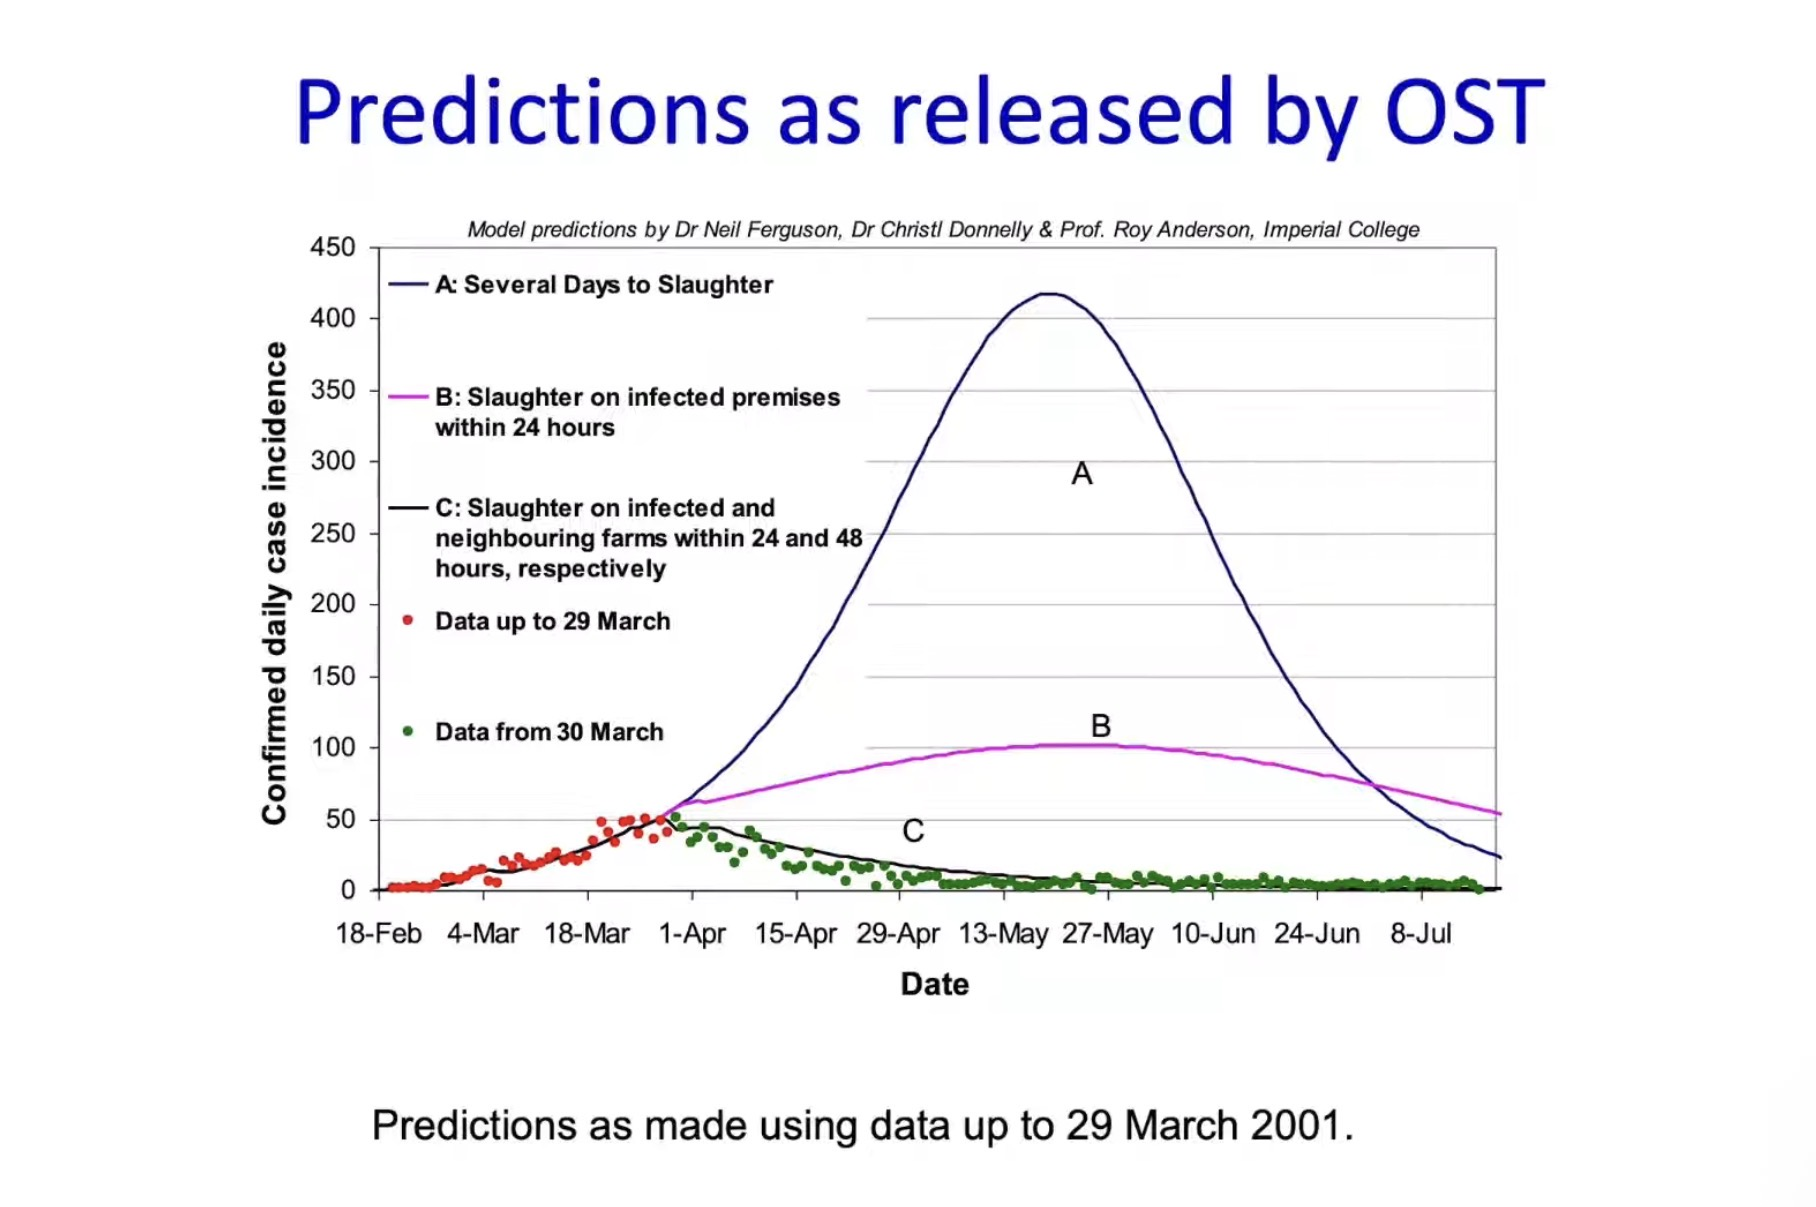

## Heatmap Logic
Quite fun: discretise curve into just points (it will be taken in as data points themselves, so this is not an issue).

- split plot into regions

Let's assume that you wanted $n$ subdivisions and the area of the current plot `x_max` $\times$ `y_max` is $A_0$.

There will exist $n^n$ rectangles that equally subdivide the space, each with area
$$A_s = \frac{A_0}{n^n}$$

- get ratio of filled area of a given colour to the area of the square, $A_s$

- compute the value of $\frac{A}{A_s}$, which is strictly between 0 and 1, and then attribute that to a colormap (lik earlier compPhysi).

In [16]:
def heatmap_data(x_data, y_data, optimal_segments):
    x_data, y_data = np.asarray(x_data), np.asarray(y_data)   # lets lists work too
    n = round(sqrt(optimal_segments))
    x_max = np.max(x_data) + 1e-9      # nudge so the max point isn't excluded by the '<' bound
    y_max = np.max(y_data) + 1e-9
    seg_l, seg_w = x_max/n, y_max/n

    colour_list = []
    for l_i in range(n):
        in_col = (seg_l * l_i <= x_data) & (x_data < seg_l * (l_i + 1))    # points in this time column
        col_n = in_col.sum()
        for w_i in range(n):
            in_cell = in_col & (seg_w * w_i <= y_data) & (y_data < seg_w * (w_i + 1))
            colour_list.append(in_cell.sum() / col_n)   # share of the column's points in this cell

    # colour_list[l_i*n + w_i] is column l_i (time), row w_i (infectives)
    return colour_list, n, seg_l, seg_w

In [17]:
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

For this test to be successful, the culling algorithms need to return list values in a transposed manner:

```
culling(params):
    return S, I, D, dt
```

The form of the lists will be, e.g. `S = [[s_data_t=0],[s_data_t=1], ..., [s_data_t=n]]` where the length of each of the sublists is the number of iterations that have been ran.

Following this plot, I can also use the data to plot a line of best fit (using existing modules, I can ask if learning the maths is really necessary) and then would be able to compare results from different plots (the time axis would just be the length of the long list).

In [18]:
def culling(dead_time, iterations, simulation_duration, neighbour_culling = False):
    # subsequent model will use population (and have some uncertainty to account for testing and false positives
    census = np.array([G.nodes[node]['N'] for node in G.nodes])
    census = census.sum()

    S, I, D = [], [], []
    dt = 1/24 # hour; how to include counter that could be agnostic to whatever dt is

    for itr in range(iterations):
        for node in G.nodes:
            # resets
            G.nodes[node]["S"] = [int(G.nodes[node]["N"])]
            G.nodes[node]["I"] = [0]
            G.nodes[node]["D"] = [0]
            G.nodes[node]["dS"] = 0
            G.nodes[node]["dI"] = 0
            G.nodes[node]["dD"] = 0
            G.nodes[node]["counter"] = 0
            G.nodes[node]["detected"] = False
            G.nodes[node]["culled"] = False

        time_range = simulation_duration # days

        for step in range(int(time_range / dt)):
            for node in G.nodes:
                if not G.nodes[node]["culled"]:
                    inter_farm(node, dt, step)

            for node in G.nodes:
                if G.nodes[node]["culled"]:
                    G.nodes[node]["S"].append(0)
                    G.nodes[node]["I"].append(0)
                    G.nodes[node]["D"].append(G.nodes[node]["N"])
                    continue

                delta_helper(node)

                if G.nodes[node]["dI"] > 0 and not G.nodes[node]["detected"]:
                    G.nodes[node]["detected"] = True

                if G.nodes[node]["detected"]:
                    G.nodes[node]["counter"] += 1 #counter. in unit dependent on dt

                if G.nodes[node]["counter"] >= dead_time:
                    # override the calculated value
                    G.nodes[node]["culled"] = True

                    G.nodes[node]["D"][-1] = G.nodes[node]["N"]
                    G.nodes[node]["S"][-1] = 0
                    G.nodes[node]["I"][-1] = 0

        # collect the sum of attributes across the network
        s_matrix = np.array([G.nodes[node]['S'] for node in G.nodes])
        s = s_matrix.sum(axis=0).tolist()

        i_matrix = np.array([G.nodes[node]['I'] for node in G.nodes])
        i = i_matrix.sum(axis=0).tolist()

        d_matrix = np.array([G.nodes[node]['D'] for node in G.nodes])
        d = d_matrix.sum(axis=0).tolist()

        S.append(s)
        D.append(d)
        I.append(i)

    return np.array(S).transpose().tolist(), np.array(I).transpose().tolist(), np.array(D).transpose().tolist(), dt

In [30]:
S, I, D, dt = culling(48, 3000, 1) #48 hour dead time, 300 iteration runs, 3 day plotting

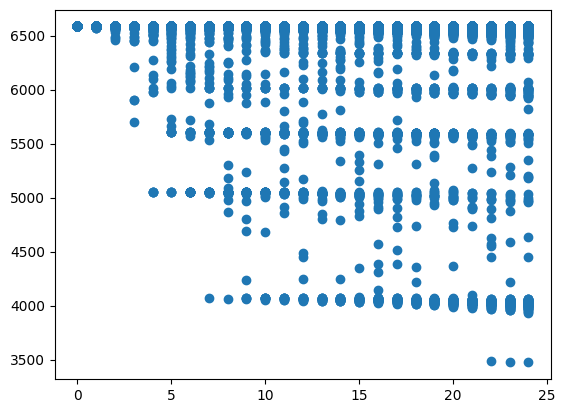

In [33]:
data = S
plt.scatter(np.repeat(np.arange(len(data)), len(data[0])), np.array(data).ravel())

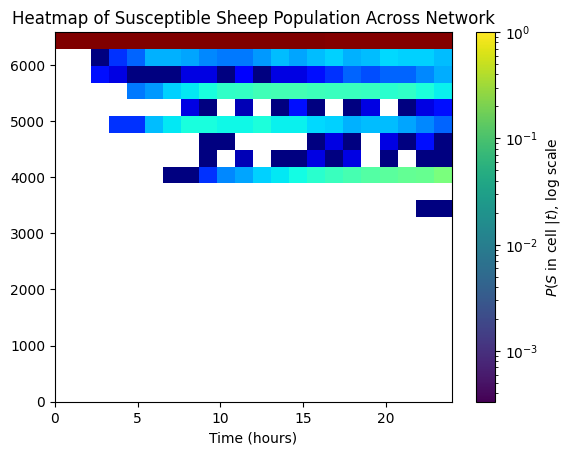

In [36]:
from matplotlib.colors import LogNorm # log plot was used in SciBySim
fig, ax = plt.subplots()
x_data = np.repeat(np.arange(len(S)), len(S[0]))
y_data = np.array(S).ravel() #flattens the matrix value

colour_list, n, w, h = heatmap_data(x_data, y_data, 500)

nz = [v for v in colour_list if v > 0] # since ln(x) undefined for x <= 0
norm = LogNorm(vmin=min(nz), vmax=max(nz))
colours = [plt.cm.jet(norm(v)) if v > 0 else (1, 1, 1, 1) for v in colour_list] #empty cells white

coords = [(w * l_i, h * w_i) for l_i in range(n) for w_i in range(n)]

rects = [Rectangle((x0, y0), w, h, facecolor=c) for (x0, y0), c in zip(coords, colours)]
coll = PatchCollection(rects, match_original=True, edgecolor='none')

ax.add_collection(coll)
ax.autoscale()
ax.set_title("Heatmap of Susceptible Sheep Population Across Network")
ax.set_xlim(0, max(x_data))
ax.set_ylim(0, max(y_data))
ax.set_xlabel("Time (hours)")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=ax,
             label=r'$P(S \text{ in cell } | t)$, log scale')
plt.show()


Now with this better visualisation, I will focus on actually conducting some data analysis:

- produce a line of best fit through the data (of suscpetibles)
- compare RMSE with different appraoches (quadratic, cubic, exponential (esp. for susceptibles following decay))
- extract these stats in differences

Following this, the first phase of this project would have been completed. I will reach out to some professionals to explore what other things are done within disease outbreaks and how to refine the model in more detail.

Given my assumption for exponential decay, the resultant formula for the curve would be:

$$y = \lambda e^{\mu t} + \beta$$

I will also run this such that it would be piecewise, where prior to. culling there is some prediction of the curve and its progression and the same is true afterwards (which helps with analysis).

As with any model, I am trying to reduce the sum of squared erros against data points (SSE) and viven the three unknowns here (although the process is typical), I will use partial differentiation.

$$\lambda e^{\mu t} + \beta - y = 0$$

$$SSE = \sum_{i \in N}^N(\lambda e^{\mu t_i} + \beta - y_i)^2$$

Where $t_i$ is just the discrete time step and $y_i$ is the corresponding data point.

Now have reached a problem of optimisation, where I would like a direct analytical solution to this, but that seems unlikely so I will try to learn approaches in this optimisation to be able to do this comparison and be done with this.

An approach I thought of was taking the natural log of both sides as below:

$$\ln{y - \beta} = \ln{\lambda} + \mu t$$

$$\ln{\frac{y - \beta}{\lambda}} - \mu t = 0$$

But there are still three variables and I don't really understand what I could do with that -- after approaching this through different optimisation techniques, I will see what approaches exist with a 'linear  model'.

Unfortunately, I can't larp knowledge about linear regression anymore.

### Linear Regression
*This will use notes from the SciBySim book, and I will see how, within the surface, can do gradient descent. It intuitively seems like the general case of the Newton Raphson*

Firstly, I want to plot a cube.

In [ ]:
# to visualise this minimisation task, I would like to plot the cube of values of varying combinations of the three unknown variables

This function will be $S(\lambda, \mu, \beta)$ and will a cub. To represent the 4th dimension, I will vary the alpha values of the plots to show where some local minima will be.

$$\overline{SSE} = \frac{1}{N}\sum_{i \in N}^N(\lambda e^{\mu t_i} + \beta - y_i)^2$$


In [ ]:
lambd = np.linspace(0,1,10)
mu = np.linspace(0,1,10)
beta = np.linspace(0,1,10)
t = x_data
y = y_data
N = len(x_data)

SSE_bar = 1/N * np.sum(lambd*np.exp(mu))

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(lamdb, mu, beta, alpha=SSE_bar)

ax.set_xlabel(r'\lambda')
ax.set_ylabel(r'\mu')
ax.set_zlabel(r'\beta')

plt.show()